In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
pd.set_option("display.max_columns", 100)

In [5]:
manual_df = pd.read_csv("../data/data_with_manual_premiums.csv")
kmeans_df = pd.read_csv("../data/premium_kmeans_only.csv")

print(len(manual_df), len(kmeans_df))

# Merge on a stable column (Age + Income + Premium Amount)
df = manual_df.merge(
    kmeans_df,
    on=["Age", "Annual Income", "Health Score", "Credit Score",
        "Previous Claims", "Vehicle Age", "Smoking Status",
        "Premium Amount"],
    how="inner"
)

print("Merged rows:", len(df))
df.head()

1200000 1200000
Merged rows: 657011


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Risk_Class,Risk_Label,Manual_Rule_Premium,Manual_Ideal_Premium,Manual_RF_Premium,KMeans_Risk_Class,KMeans_Risk_Label,Premium_KMeans_RuleBased,Ideal_KMeans_Premium,Premium_KMeans_RF
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,Medium Risk,623.700000,949.816048,999.964983,2,High Risk,779.625000,1499.632095,1594.398282
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,2,High Risk,975.505781,1960.571445,1599.645981,1,Medium Risk,780.404625,1180.285723,999.719562
2,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,1,Medium Risk,693.242550,1039.463394,1000.380679,1,Medium Risk,693.242550,1039.463394,996.300311
3,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,1,Medium Risk,526.500000,862.407456,999.303377,1,Medium Risk,526.500000,862.407456,998.256721
4,5,29.0,Male,45963.0,Married,1.0,Bachelor's,NaN,33.053198,Urban,Premium,2.0,4.0,614.0,5.0,2022-05-20 15:21:39.207847,Average,No,Weekly,House,3202.0,0,Low Risk,363.588750,462.397808,599.922940,0,Low Risk,363.588750,462.397808,597.998896


In [6]:
df = df.rename(columns={
    "Manual_Rule_Premium": "Manual_Rule",
    "Manual_RF_Premium": "Manual_RF",
    "Manual_Ideal_Premium": "Manual_Ideal",

    "Premium_KMeans_RuleBased": "KMeans_Rule",
    "Premium_KMeans_RF": "KMeans_RF",
    "Ideal_KMeans_Premium": "KMeans_Ideal",
})

cols = ["Manual_Rule", "Manual_RF", "Manual_Ideal",
        "KMeans_Rule", "KMeans_RF", "KMeans_Ideal"]

df[cols].head()

,Manual_Rule,Manual_RF,Manual_Ideal,KMeans_Rule,KMeans_RF,KMeans_Ideal
0,623.700000,999.964983,949.816048,779.625000,1594.398282,1499.632095
1,975.505781,1599.645981,1960.571445,780.404625,999.719562,1180.285723
2,693.242550,1000.380679,1039.463394,693.242550,996.300311,1039.463394
3,526.500000,999.303377,862.407456,526.500000,998.256721,862.407456
4,363.588750,599.922940,462.397808,363.588750,597.998896,462.397808


In [7]:
summary = df[cols].agg(["mean", "median", "min", "max", "std"]).T
summary

,mean,median,min,max,std
Manual_Rule,666.779349,600.311250,252.434475,1967.269992,225.596000
Manual_RF,1151.658199,1000.184272,542.698713,1719.962324,297.734462
Manual_Ideal,1151.605426,1071.113149,400.022756,1999.994254,336.758003
KMeans_Rule,625.421574,583.537500,252.434475,1967.269992,203.080675
KMeans_RF,945.618753,998.160651,559.874390,1770.969148,372.821731
KMeans_Ideal,945.521252,870.200666,400.000333,1999.994254,400.416949


In [8]:
manual_summary = df.groupby("Risk_Class")[["Manual_Rule", "Manual_RF", "Manual_Ideal"]].mean()
kmeans_summary = df.groupby("KMeans_Risk_Class")[["KMeans_Rule", "KMeans_RF", "KMeans_Ideal"]].mean()

print("Manual Risk Pricing:")
display(manual_summary)

print("\nKMeans Risk Pricing:")
display(kmeans_summary)

Manual Risk Pricing:


,Manual_Rule,Manual_RF,Manual_Ideal
Risk_Class,,,
0,345.348244,600.276247,599.974742
1,554.957136,1000.002442,1000.022256
2,982.280285,1600.279478,1600.104039



KMeans Risk Pricing:


,KMeans_Rule,KMeans_RF,KMeans_Ideal
KMeans_Risk_Class,,,
0,466.084708,599.994880,599.898976
1,669.627910,1000.121112,999.837279
2,892.790939,1601.070261,1601.309138


In [9]:
def premium_overlap(df, method, class_col):
    stats = df.groupby(class_col)[method].agg(["min", "max"])
    print(f"\nOverlap for {method}:")
    display(stats)

for method in cols:
    premium_overlap(df, method, "Risk_Class")

for method in cols:
    premium_overlap(df, method, "KMeans_Risk_Class")    


Overlap for Manual_Rule:


,min,max
Risk_Class,,
0,252.434475,413.343000
1,377.950506,825.000000
2,750.651699,1967.269992



Overlap for Manual_RF:


,min,max
Risk_Class,,
0,542.698713,657.422259
1,954.205164,1073.285454
2,1402.675695,1719.962324



Overlap for Manual_Ideal:


...

,min,max
KMeans_Risk_Class,,
0,252.434475,915.234532
1,364.627575,1322.005435
2,452.093906,1967.269992



Overlap for KMeans_RF:


,min,max
KMeans_Risk_Class,,
0,559.874390,683.378757
1,986.096514,1016.381665
2,1519.960033,1770.969148



Overlap for KMeans_Ideal:


,min,max
KMeans_Risk_Class,,
0,400.000333,799.999326
1,800.002994,1199.996776
2,1200.004429,1999.994254


In [10]:
def monotonicity(df, method, class_col):
    stats = df.groupby(class_col)[method].mean().values
    return stats[0] < stats[1] < stats[2]

for method in cols:
    print(method, "→ Manual Classes Monotonic?", monotonicity(df, method, "Risk_Class"))

for method in cols:
    print(method, "→ KMeans Classes Monotonic?", monotonicity(df, method, "KMeans_Risk_Class"))

Manual_Rule → Manual Classes Monotonic? True
Manual_RF → Manual Classes Monotonic? True
Manual_Ideal → Manual Classes Monotonic? True
KMeans_Rule → Manual Classes Monotonic? True
KMeans_RF → Manual Classes Monotonic? True
KMeans_Ideal → Manual Classes Monotonic? True
Manual_Rule → KMeans Classes Monotonic? True
Manual_RF → KMeans Classes Monotonic? True
Manual_Ideal → KMeans Classes Monotonic? True
KMeans_Rule → KMeans Classes Monotonic? True
KMeans_RF → KMeans Classes Monotonic? True
KMeans_Ideal → KMeans Classes Monotonic? True


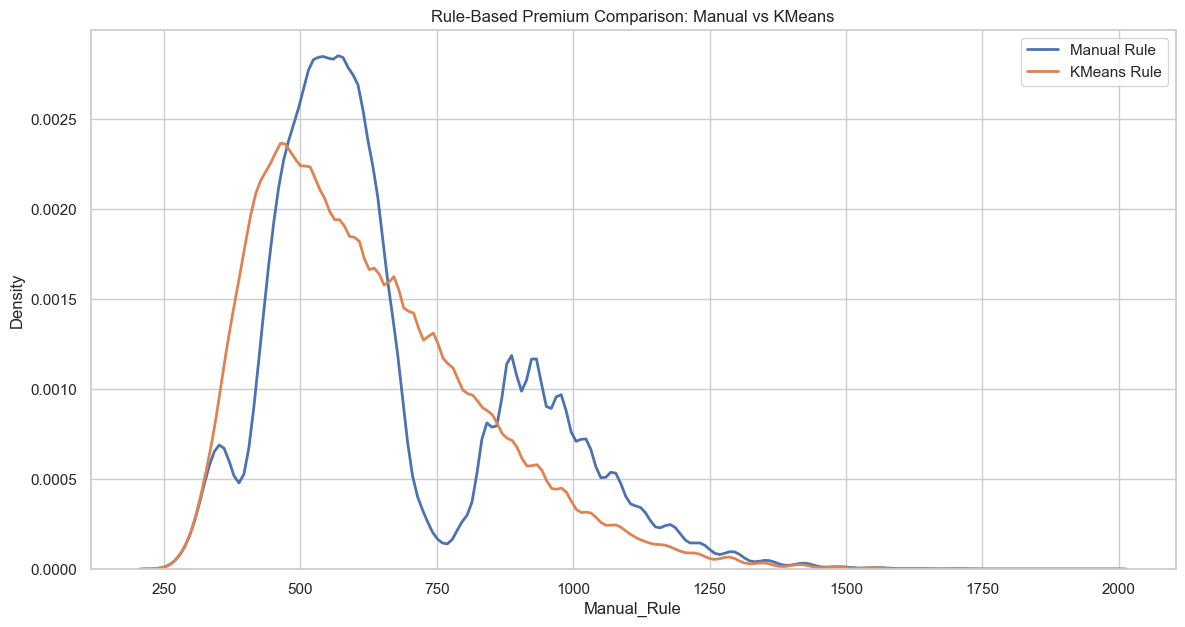

In [11]:
plt.figure(figsize=(14, 7))

sns.kdeplot(df["Manual_Rule"], label="Manual Rule", linewidth=2)
sns.kdeplot(df["KMeans_Rule"], label="KMeans Rule", linewidth=2)

plt.title("Rule-Based Premium Comparison: Manual vs KMeans")
plt.legend()
plt.show()

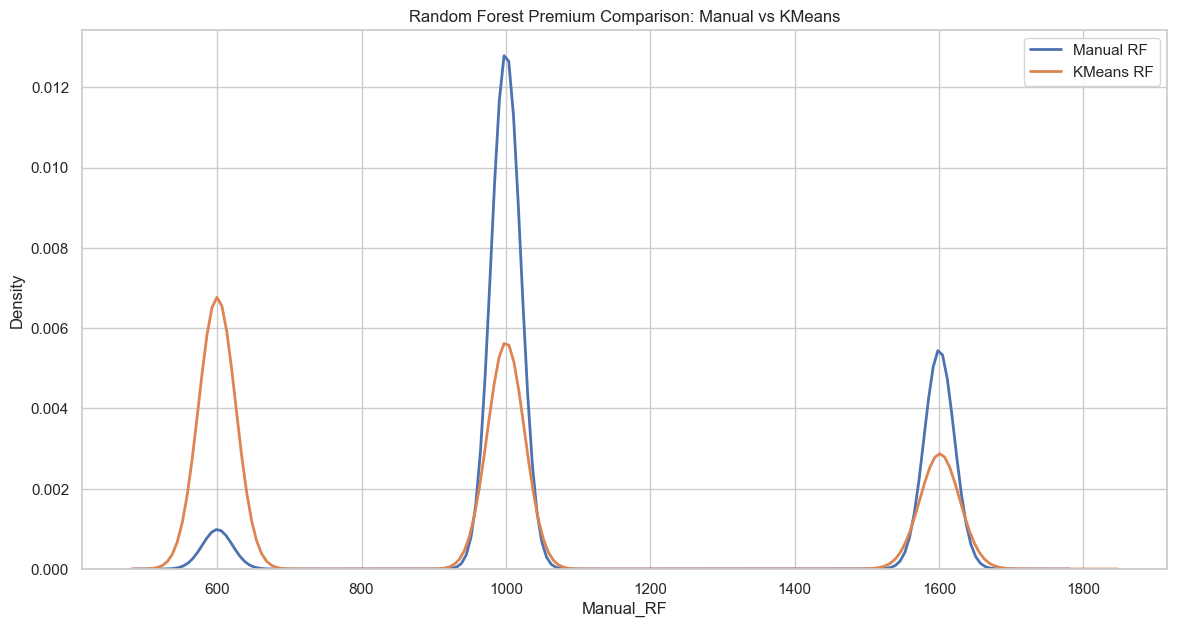

In [12]:
plt.figure(figsize=(14, 7))

sns.kdeplot(df["Manual_RF"], label="Manual RF", linewidth=2)
sns.kdeplot(df["KMeans_RF"], label="KMeans RF", linewidth=2)

plt.title("Random Forest Premium Comparison: Manual vs KMeans")
plt.legend()
plt.show()

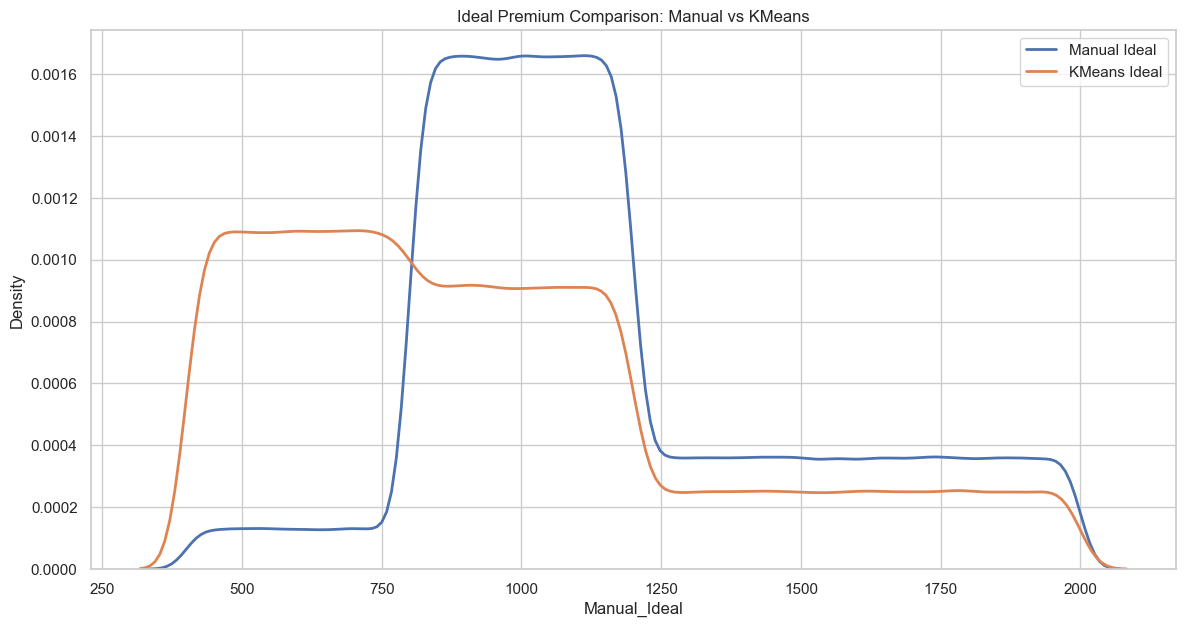

In [13]:
plt.figure(figsize=(14, 7))

sns.kdeplot(df["Manual_Ideal"], label="Manual Ideal", linewidth=2)
sns.kdeplot(df["KMeans_Ideal"], label="KMeans Ideal", linewidth=2)

plt.title("Ideal Premium Comparison: Manual vs KMeans")
plt.legend()
plt.show()

In [14]:
df["Delta_Rule"] = df["KMeans_Rule"] - df["Manual_Rule"]
df["Delta_RF"]   = df["KMeans_RF"] - df["Manual_RF"]

df[["Delta_Rule", "Delta_RF"]].describe()

,Delta_Rule,Delta_RF
count,657011.000000,657011.000000
mean,-41.357775,-206.039446
std,97.318454,362.510706
min,-437.026590,-1057.954748
25%,-61.746300,-401.649555
50%,-44.887500,-398.437578
75%,0.000000,0.761068
max,349.613086,1108.593401


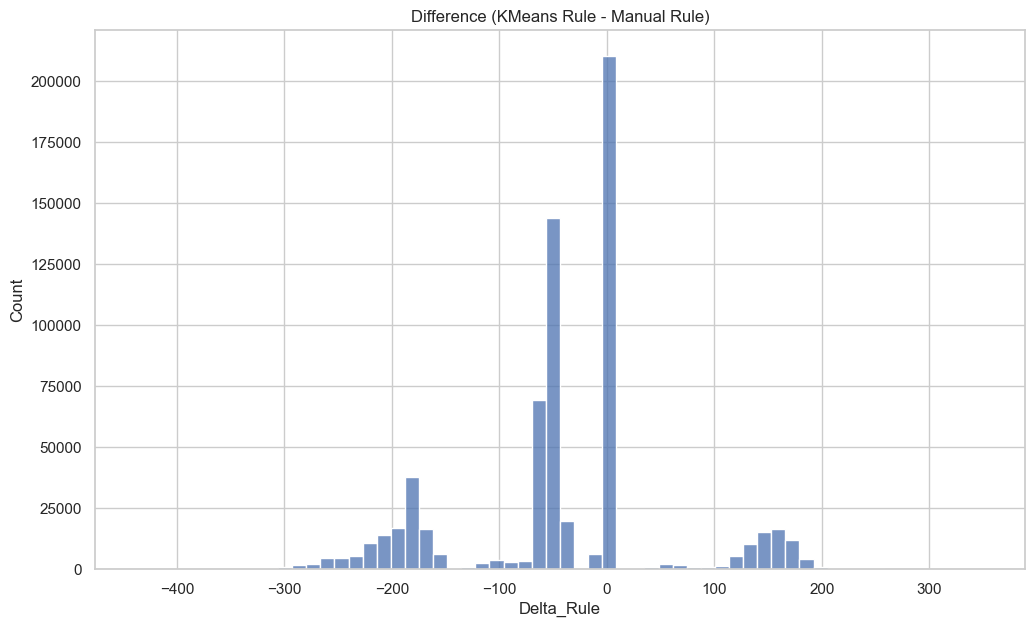

In [15]:
sns.histplot(df["Delta_Rule"], bins=60)
plt.title("Difference (KMeans Rule - Manual Rule)")
plt.show()

In [16]:
migration = pd.crosstab(df["Risk_Class"], df["KMeans_Risk_Class"])
migration

KMeans_Risk_Class,0,1,2
Risk_Class,,,
0,32858,112,886
1,245009,123638,65974
2,8662,115541,64331


In [17]:
df["Risk_Combo"] = df["Risk_Class"].astype(str) + "→" + df["KMeans_Risk_Class"].astype(str)

combo_summary = df.groupby("Risk_Combo")[["Manual_Rule", "KMeans_Rule"]].mean()
combo_summary

,Manual_Rule,KMeans_Rule
Risk_Combo,,
0→0,344.439924,344.448976
0→1,336.646521,374.051690
0→2,380.134014,528.800316
1→0,527.781670,474.949643
1→1,578.791332,578.834069
1→2,611.212956,764.191253
2→0,939.849890,676.742550
2→1,958.981545,767.071012
2→2,1029.838877,1029.688103


In [18]:
df.to_csv("../data/policy_evaluation_full.csv", index=False)
print("Saved policy evaluation dataset ✓")

Saved policy evaluation dataset ✓
